## ⚙️ **Libraries Import**

In [ ]:
# Set seed for reproducibility
SEED = 64

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

!pip install transformers
from transformers import AutoModel

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

## ⏳ **Data Loading**

In [2]:
# Path Setup based on your description
DATASET_ROOT = os.path.join('/kaggle/input', 'ann-c2/Dataset')
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train_data') # Contains BOTH images and masks
TEST_DIR = os.path.join(DATASET_ROOT, 'test_data')
LABEL_FILE = os.path.join(DATASET_ROOT, 'train_labels.csv')

print(f"Training Data Directory: {TRAIN_DIR}")
print(f"Labels File: {LABEL_FILE}")

Training Data Directory: /kaggle/input/ann-c2/Dataset/train_data
Labels File: /kaggle/input/ann-c2/Dataset/train_labels.csv


In [3]:
def prepare_data_splits():
    """
    Reads the CSV and creates 80/20 Train/Val split lists.
    Reads the Test Directory for Inference lists.
    """
    # 1. Load Labels CSV
    df = pd.read_csv(LABEL_FILE)

    # Map text labels to integers if needed
    if 'label_idx' not in df.columns:
        label_map = {'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}
        df['label_idx'] = df['label'].map(label_map)

    # 2. Split into Train (80%) and Validation (20%)
    # We use 'sample_index' (filename) and 'label_idx' columns
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=SEED,
        stratify=df['label_idx']
    )

    print(f"Training Samples: {len(train_df)}")
    print(f"Validation Samples: {len(val_df)}")

    # 3. Prepare Test Data (Inference)
    # Since there is no CSV for test, we scan the directory
    # Filter for 'img_' to avoid picking up masks or other files
    test_files = [f for f in os.listdir(TEST_DIR) if f.startswith("img_") and f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Inference Test Samples: {len(test_files)}")

    return train_df, val_df, test_files

# Execute the split
train_df, val_df, test_files = prepare_data_splits()

Training Samples: 464
Validation Samples: 117
Inference Test Samples: 477


In [4]:
# Image and Batch Size config
IMG_SIZE = 224
BATCH_SIZE = 16

In [5]:
# Standard ResNet Input Shape
input_shape = (3, IMG_SIZE, IMG_SIZE)
num_classes = 4 # Based on your 4 subtypes

print("Input Shape:", input_shape)
print("Number of Classes:", num_classes)

Input Shape: (3, 224, 224)
Number of Classes: 4


In [6]:
class GrumpyDoctogresDataset(torch.utils.data.Dataset):
    def __init__(self, samples, data_dir, labels=None, transform=None, patch_size=224, crops_per_image=1):
        """
        Args:
            crops_per_image (int): Number of different crops to generate from each image per epoch.
                                   Default is 1 (standard behavior).
        """
        self.samples = samples
        self.labels = labels
        self.data_dir = data_dir
        self.transform = transform
        self.patch_size = patch_size
        self.crops_per_image = crops_per_image

    def __len__(self):
        # Virtually increase dataset size by the multiplier
        return len(self.samples) * self.crops_per_image

    def __getitem__(self, idx):
        # Map the virtual index back to the actual sample index
        original_idx = idx % len(self.samples)

        img_filename = self.samples[original_idx]
        img_path = os.path.join(self.data_dir, img_filename)

        # 1. Load Image
        image = Image.open(img_path).convert('RGB')
        w, h = image.size

        # 2. Load Mask
        mask_filename = img_filename.replace('img_', 'mask_').rsplit('.', 1)[0] + '.png'
        mask_path = os.path.join(self.data_dir, mask_filename)

        # --- POSITIVE-PIXEL SAMPLING ---
        # Default center if no mask exists
        crop_center_y, crop_center_x = h // 2, w // 2

        if os.path.exists(mask_path):
            mask = Image.open(mask_path).convert('L')
            mask_np = np.array(mask)

            # Find all coordinates that are REAL tissue (pixel value > 0)
            y_indices, x_indices = np.where(mask_np > 0)

            if len(y_indices) > 0:
                # Pick ONE random tissue pixel to be the center
                # Because this is called multiple times per epoch (crops_per_image > 1),
                # we get different centers each time.
                random_idx = np.random.randint(len(y_indices))
                crop_center_y = y_indices[random_idx]
                crop_center_x = x_indices[random_idx]

        # 3. Calculate Crop Box
        half_size = self.patch_size // 2

        top = max(0, crop_center_y - half_size)
        left = max(0, crop_center_x - half_size)

        # Adjust if box goes off-edge
        if top + self.patch_size > h: top = max(0, h - self.patch_size)
        if left + self.patch_size > w: left = max(0, w - self.patch_size)

        # 4. Perform the Crop
        image = image.crop((left, top, left + self.patch_size, top + self.patch_size))

        # Fallback resize if image was smaller than patch_size
        if image.size != (self.patch_size, self.patch_size):
             image = image.resize((self.patch_size, self.patch_size), Image.BILINEAR)

        # 5. Apply Transforms (RandAugment, Normalization)
        if self.transform:
            image = self.transform(image)

        if self.labels is not None:
            return image, self.labels[original_idx] # Use original_idx for labels too
        return image, img_filename

In [7]:
import torch.nn.functional as F

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        p_left = (max_wh - w) // 2
        p_top = (max_wh - h) // 2
        p_right = max_wh - w - p_left
        p_bottom = max_wh - h - p_top

        # Add padding (fill=0 is black)
        return transforms.functional.pad(image, (p_left, p_top, p_right, p_bottom), fill=0, padding_mode='constant')

# --- Updated Transforms ---

train_transform = transforms.Compose([
    # Advice 06/12: "The chaos the machine chooses"
    # num_ops=2: Apply 2 random distortions per image
    # magnitude=9: Strength of distortion (0-30 scale)
    transforms.RandAugment(num_ops=2, magnitude=9),

    # Standard stuff
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# For validation, ONLY normalize (no chaos!)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """Create a PyTorch DataLoader with optimized settings."""
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

##  🧠 **Training Functions**

In [9]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1


def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy


def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

##  🧮 **Network Parameters**



In [10]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [11]:
# Training parameters
LEARNING_RATE = 1e-4

EPOCHS = 30
PATIENCE = 15
CROPS_PER_IMAGE = 10

# Regularization
DROPOUT_RATE = 0.5

# Set up loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("Patience:", PATIENCE)

Epochs: 30
Batch Size: 16
Learning Rate: 0.0001
Dropout Rate: 0.5
Patience: 15


## 🛠️ **Transfer Learning**





In [12]:
# [Cell 15] - REPLACEMENT
class PhikonPathology(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5, freeze_backbone=True):
        super().__init__()
        
        # 1. Load Phikon (ViT-Base pre-trained on 40M pathology tiles)
        print("Loading Phikon from Hugging Face...")
        self.backbone = AutoModel.from_pretrained("owkin/phikon", add_pooling_layer=False)

        # 2. Freeze backbone weights if requested
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 3. Specialist Head
        # Phikon (ViT-Base) outputs 768-dimensional features
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        # ViT expects input shape (B, 3, 224, 224)
        outputs = self.backbone(x)
        
        # Extract the [CLS] token (index 0) which represents the whole image
        # Shape: (Batch_Size, 768)
        cls_token = outputs.last_hidden_state[:, 0, :]
        
        logits = self.head(cls_token)
        return logits

In [ ]:
# [Cell 16] - UPDATE INSTANTIATION
# Create transfer learning model using the new Pathology class
tl_model = PhikonPathology(num_classes, DROPOUT_RATE, freeze_backbone=True).to(device)

# Display model summary
#summary(tl_model, input_size=input_shape)

In [14]:
# --- Training Dataset ---\n
# Generate 10 random crops per image per epoch
train_dataset = GrumpyDoctogresDataset(
    samples=train_df['sample_index'].tolist(),
    labels=train_df['label_idx'].tolist(),
    data_dir=TRAIN_DIR,
    transform=train_transform,
    crops_per_image=CROPS_PER_IMAGE
)

# --- Validation Dataset ---
# Keep validation deterministic/single crop (crops_per_image=1 by default)
val_dataset = GrumpyDoctogresDataset(
    samples=val_df['sample_index'].tolist(),
    labels=val_df['label_idx'].tolist(),
    data_dir=TRAIN_DIR,
    transform=val_transform
)

# --- Test (Inference) Dataset ---
test_dataset = GrumpyDoctogresDataset(
    samples=test_files,
    labels=None,
    data_dir=TEST_DIR,
    transform=val_transform
)

# --- Data Loaders ---
# NOTE: Since the dataset is now larger, you might want to adjust batch size or workers if RAM is tight,
# though usually it stays the same.
train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_dataset, BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = make_loader(test_dataset, BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Original Training Samples: {len(train_df)}")
print(f"Augmented Training Samples: {len(train_dataset)}")
print("\\nDataLoaders created successfully.")

Original Training Samples: 464
Augmented Training Samples: 4640
\nDataLoaders created successfully.


In [15]:
# Setup training
experiment_name = "transfer_learning"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)

optimizer = torch.optim.AdamW(
    tl_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-3
)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [16]:
%%time
# Train with transfer learning
tl_model, tl_history = fit(
    model=tl_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="transfer_learning",
    patience=PATIENCE
)

Training 30 epochs...
Epoch   1/30 | Train: Loss=1.6762, F1 Score=0.2715 | Val: Loss=1.3571, F1 Score=0.3268
Epoch   2/30 | Train: Loss=1.5885, F1 Score=0.3017 | Val: Loss=1.3769, F1 Score=0.2917
Epoch   3/30 | Train: Loss=1.5139, F1 Score=0.3130 | Val: Loss=1.3365, F1 Score=0.3378
Epoch   4/30 | Train: Loss=1.4620, F1 Score=0.3371 | Val: Loss=1.3547, F1 Score=0.3331
Epoch   5/30 | Train: Loss=1.4292, F1 Score=0.3307 | Val: Loss=1.3708, F1 Score=0.2590
Epoch   6/30 | Train: Loss=1.3920, F1 Score=0.3483 | Val: Loss=1.3381, F1 Score=0.3373
Epoch   7/30 | Train: Loss=1.3558, F1 Score=0.3563 | Val: Loss=1.3624, F1 Score=0.3259
Epoch   8/30 | Train: Loss=1.3440, F1 Score=0.3633 | Val: Loss=1.3401, F1 Score=0.3402
Epoch   9/30 | Train: Loss=1.3439, F1 Score=0.3731 | Val: Loss=1.3552, F1 Score=0.3433
Epoch  10/30 | Train: Loss=1.3320, F1 Score=0.3666 | Val: Loss=1.3494, F1 Score=0.3206
Epoch  11/30 | Train: Loss=1.3139, F1 Score=0.3708 | Val: Loss=1.4414, F1 Score=0.2609
Epoch  12/30 | Train:

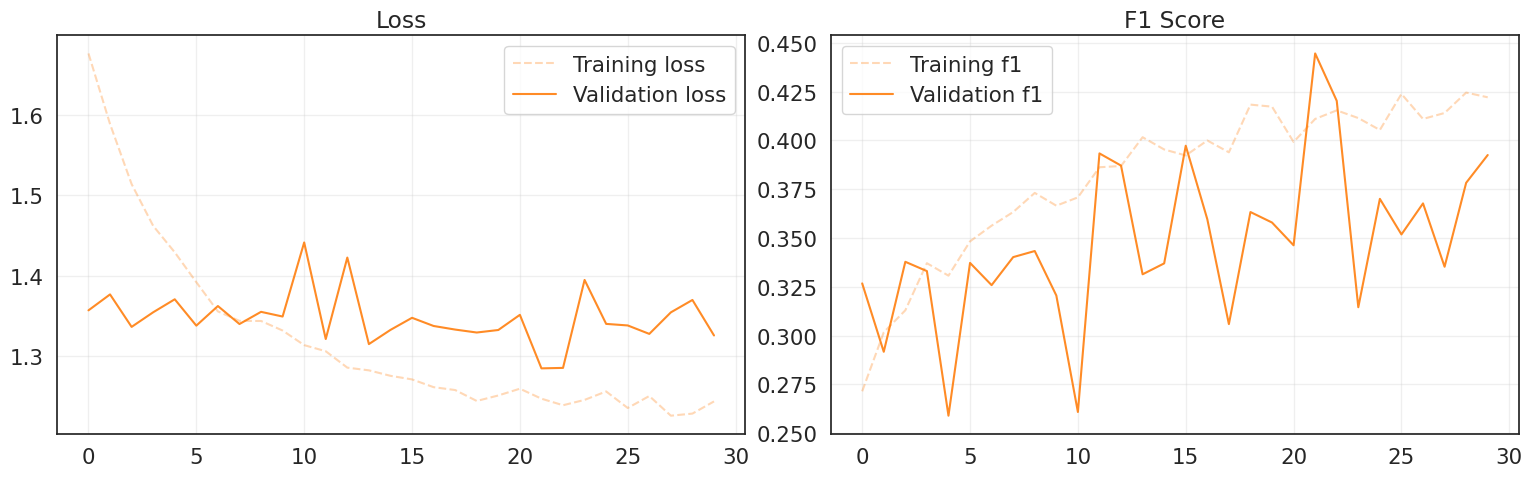

In [17]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(tl_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(tl_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(tl_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(tl_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## 🛠️ **Fine-Tuning**

In [18]:
# [Cell 21] - UPDATE FINE-TUNING INSTANTIATION
# Load the transfer learning model
ft_model = PhikonPathology(num_classes, DROPOUT_RATE, freeze_backbone=False).to(device)

# Load weights from the transfer learning phase
# Note: Ensure the filename matches what you saved in the TL phase
ft_model.load_state_dict(torch.load("models/transfer_learning_model.pt"))

# --- Updated Unfreezing Logic for ResNet50 ---

ft_model = PhikonPathology(num_classes, DROPOUT_RATE, freeze_backbone=False).to(device)
ft_model.load_state_dict(torch.load("models/transfer_learning_model.pt"))

# --- Phikon Fine-Tuning Strategy ---
# ViTs don't have "blocks" like ResNet. They have "Layers".
# We unfreeze the last 2 Transformer layers.
for param in ft_model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers of the encoder
# Phikon's encoder is named 'encoder' and has 'layer' list
for param in ft_model.backbone.encoder.layer[-2:].parameters():
    param.requires_grad = True

Loading Phikon from Hugging Face...


Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initiali

Loading Phikon from Hugging Face...


In [19]:
# --- Training Dataset ---\n
# Generate 10 random crops per image per epoch
train_dataset = GrumpyDoctogresDataset(
    samples=train_df['sample_index'].tolist(),
    labels=train_df['label_idx'].tolist(),
    data_dir=TRAIN_DIR,
    transform=train_transform,
    crops_per_image=CROPS_PER_IMAGE
)

# --- Validation Dataset ---
# Keep validation deterministic/single crop (crops_per_image=1 by default)
val_dataset = GrumpyDoctogresDataset(
    samples=val_df['sample_index'].tolist(),
    labels=val_df['label_idx'].tolist(),
    data_dir=TRAIN_DIR,
    transform=val_transform
)

# --- Test (Inference) Dataset ---
test_dataset = GrumpyDoctogresDataset(
    samples=test_files,
    labels=None,
    data_dir=TEST_DIR,
    transform=val_transform
)

# --- Data Loaders ---
# NOTE: Since the dataset is now larger, you might want to adjust batch size or workers if RAM is tight,
# though usually it stays the same.
train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_dataset, BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = make_loader(test_dataset, BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Original Training Samples: {len(train_df)}")
print(f"Augmented Training Samples: {len(train_dataset)}")
print("\\nDataLoaders created successfully.")

Original Training Samples: 464
Augmented Training Samples: 4640
\nDataLoaders created successfully.


In [20]:
# OSS: fine-tuning needs a lower learning rate
experiment_name = "fine_tuning"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)

FT_LEARNING_RATE = 5e-6
optimizer = torch.optim.AdamW(
    ft_model.parameters(),
    lr=FT_LEARNING_RATE,
    weight_decay=1e-3
)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

In [21]:
%%time
# Fine-tune the model
ft_model, ft_history = fit(
    model=ft_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS + 50,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="fine_tuning",
    patience=PATIENCE
)

Training 80 epochs...
Epoch   1/80 | Train: Loss=1.2397, F1 Score=0.4152 | Val: Loss=1.3247, F1 Score=0.3434
Epoch   2/80 | Train: Loss=1.2393, F1 Score=0.4010 | Val: Loss=1.3357, F1 Score=0.3867
Epoch   3/80 | Train: Loss=1.2174, F1 Score=0.4298 | Val: Loss=1.3223, F1 Score=0.4164
Epoch   4/80 | Train: Loss=1.2119, F1 Score=0.4310 | Val: Loss=1.3451, F1 Score=0.3958
Epoch   5/80 | Train: Loss=1.2141, F1 Score=0.4405 | Val: Loss=1.2920, F1 Score=0.3787
Epoch   6/80 | Train: Loss=1.2129, F1 Score=0.4291 | Val: Loss=1.2948, F1 Score=0.3995
Epoch   7/80 | Train: Loss=1.1820, F1 Score=0.4499 | Val: Loss=1.3072, F1 Score=0.3461
Epoch   8/80 | Train: Loss=1.1779, F1 Score=0.4496 | Val: Loss=1.3657, F1 Score=0.3532
Epoch   9/80 | Train: Loss=1.1652, F1 Score=0.4616 | Val: Loss=1.3279, F1 Score=0.4367
Epoch  10/80 | Train: Loss=1.1457, F1 Score=0.4679 | Val: Loss=1.3664, F1 Score=0.3639
Epoch  11/80 | Train: Loss=1.1269, F1 Score=0.4776 | Val: Loss=1.2944, F1 Score=0.4522
Epoch  12/80 | Train:

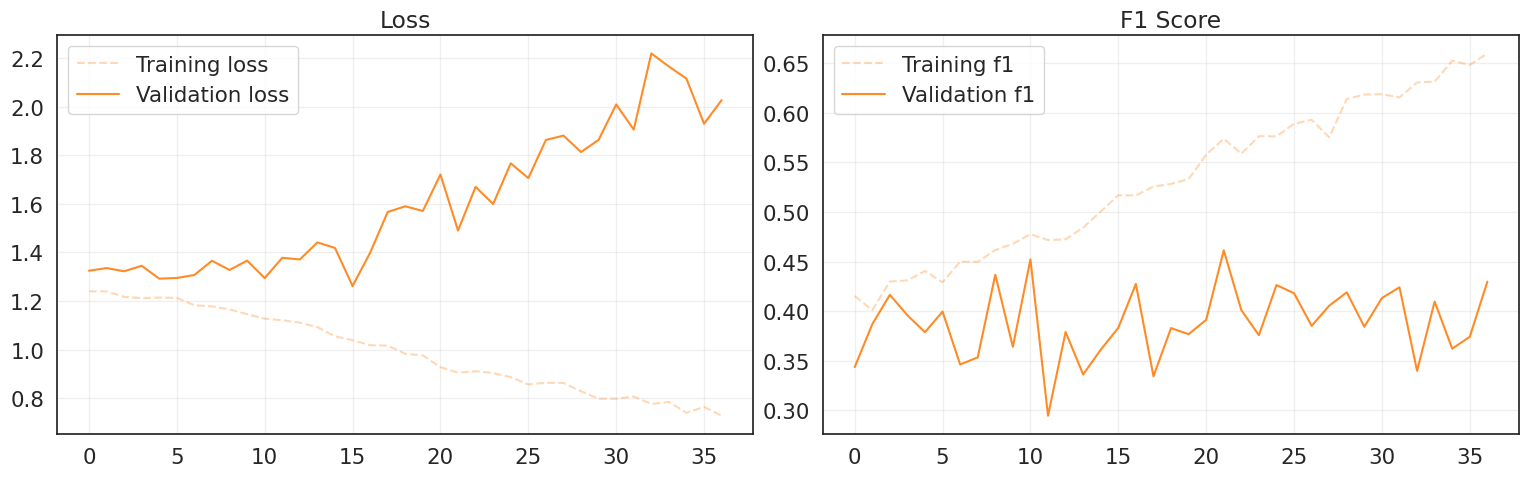

In [22]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(ft_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [23]:
# 1. Setup
label_map = {'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}
idx_to_label = {v: k for k, v in label_map.items()}

model_for_inference = ft_model if 'ft_model' in locals() else tl_model
model_for_inference.eval()

# Dictionary to store aggregated probabilities: { 'filename': [prob_class_0, prob_class_1, ...] }
file_probabilities = {}

# 2. Multi-View Inference Loop (TTA)
# We take 5 "glances" at each slide to ensure we see the tumor
N_VIEWS = 20

print(f"Starting Multi-View Inference ({N_VIEWS} crops per image)...")

with torch.no_grad():
    # Loop N times over the entire dataset
    for round_idx in range(N_VIEWS):
        print(f"  - Round {round_idx + 1}/{N_VIEWS}...")

        for images, img_names in test_loader:
            images = images.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model_for_inference(images)
                # Convert logits to probabilities (Softmax) so we can sum them safely
                probs = torch.softmax(logits, dim=1).cpu().numpy()

            # Aggregate probabilities
            for name, p in zip(img_names, probs):
                if name not in file_probabilities:
                    file_probabilities[name] = p
                else:
                    file_probabilities[name] += p

# 3. Final Decision (Soft Voting)
all_filenames = []
all_preds = []

print("Aggregating votes...")

for name, total_probs in file_probabilities.items():
    # We find the class with the highest ACCUMULATED probability
    # (No need to divide by N_VIEWS, argmax is scale-invariant)
    pred_idx = total_probs.argmax()

    all_filenames.append(name)
    all_preds.append(idx_to_label[pred_idx])

# 4. Create Submission
submission_df = pd.DataFrame({
    'sample_index': all_filenames,
    'label': all_preds
})

# 5. Save
submission_df.to_csv("submission.csv", index=False)
print("File 'submission.csv' created successfully with 5-View Voting!")
print(submission_df.head())

Starting Multi-View Inference (20 crops per image)...
  - Round 1/20...
  - Round 2/20...
  - Round 3/20...
  - Round 4/20...
  - Round 5/20...
  - Round 6/20...
  - Round 7/20...
  - Round 8/20...
  - Round 9/20...
  - Round 10/20...
  - Round 11/20...
  - Round 12/20...
  - Round 13/20...
  - Round 14/20...
  - Round 15/20...
  - Round 16/20...
  - Round 17/20...
  - Round 18/20...
  - Round 19/20...
  - Round 20/20...
Aggregating votes...
File 'submission.csv' created successfully with 5-View Voting!
   sample_index            label
0  img_0079.png        Luminal B
1  img_0072.png  Triple negative
2  img_0138.png  Triple negative
3  img_0068.png          HER2(+)
4  img_0049.png          HER2(+)


Hunting for traitors in 117 validation samples...


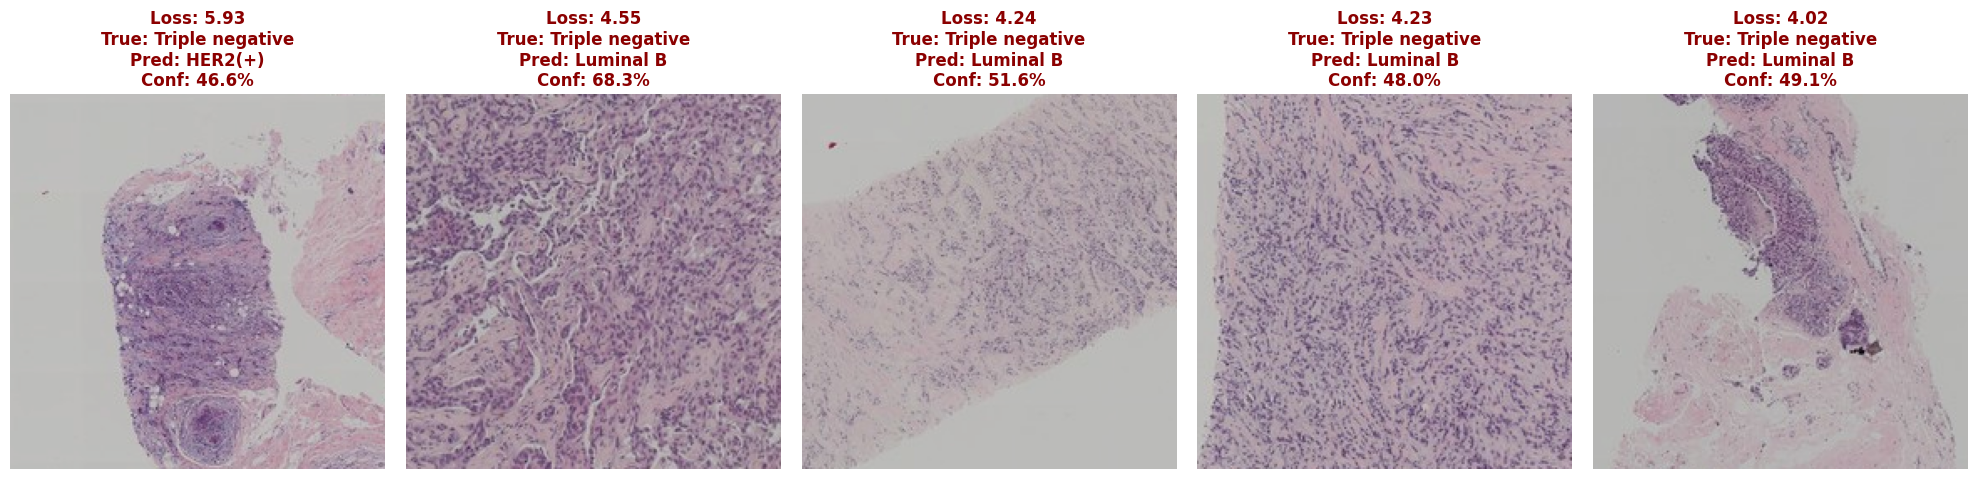

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

def find_traitors(model, val_loader, criterion, device, idx_to_label, k=5):
    """
    Identifies and plots the top k samples with the highest loss (the 'traitors').
    """
    model.eval()
    losses = []

    # 1. Define Un-normalization to make images viewable again
    # These are the standard ImageNet mean/std used in your transform
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    print(f"Hunting for traitors in {len(val_loader.dataset)} validation samples...")

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            logits = model(inputs)

            # Calculate loss per item (reduction='none' is key here!)
            batch_loss = nn.CrossEntropyLoss(reduction='none')(logits, targets)

            probs = torch.softmax(logits, dim=1)
            predictions = logits.argmax(dim=1)

            # Store data for every image in the batch
            for i in range(inputs.size(0)):
                losses.append({
                    'loss': batch_loss[i].item(),
                    'img_tensor': inputs[i].cpu(),
                    'true_idx': targets[i].item(),
                    'pred_idx': predictions[i].item(),
                    'conf': probs[i][predictions[i]].item() # Confidence of the wrong prediction
                })

    # 2. Sort by highest loss descending
    losses.sort(key=lambda x: x['loss'], reverse=True)

    # 3. Visualize the Top K
    top_k = losses[:k]

    fig, axes = plt.subplots(1, k, figsize=(4 * k, 5))
    if k == 1: axes = [axes] # Handle edge case of k=1

    for i, item in enumerate(top_k):
        ax = axes[i]

        # Convert Tensor to Numpy Image: (C, H, W) -> (H, W, C)
        img = item['img_tensor'].permute(1, 2, 0).numpy()

        # Un-normalize: pixel = (pixel * std) + mean
        img = std * img + mean
        img = np.clip(img, 0, 1) # Ensure pixel values are valid

        # Get text labels
        true_name = idx_to_label[item['true_idx']]
        pred_name = idx_to_label[item['pred_idx']]

        # Plot
        ax.imshow(img)
        ax.axis('off')

        # Color title red to emphasize error
        title = (f"Loss: {item['loss']:.2f}\n"
                 f"True: {true_name}\n"
                 f"Pred: {pred_name}\n"
                 f"Conf: {item['conf']:.1%}")
        ax.set_title(title, color='darkred', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

label_map = {'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}
idx_to_label = {v: k for k, v in label_map.items()}

find_traitors(ft_model, val_loader, criterion, device, idx_to_label, k=5)